# CELL 1 — Install packages

In [1]:
!pip -q install xgboost imbalanced-learn shap seaborn openpyxl

# CELL 2 — Imports and global configuration

In [2]:
import os
import json
import math
import random
import shutil
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier
)
from sklearn.multiclass import OneVsRestClassifier

from imblearn.over_sampling import SMOTE, ADASYN

import xgboost as xgb
import shap

from google.colab import files

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Dataset paths
DATASET_PATH = "/content/ANUBHUTI.csv"
TRANSLATED_DATASET_PATH = "/content/ANUBHUTI_Translated_Texts.csv"

# Output directory
OUTPUT_DIR = Path("/content/ANUBHUTI_Research_Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Subdirectories
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
LOG_DIR = OUTPUT_DIR / "logs"

for directory in [FIG_DIR, TABLE_DIR, MODEL_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Environment initialized successfully.")
print(f"Output directory: {OUTPUT_DIR}")

Environment initialized successfully.
Output directory: /content/ANUBHUTI_Research_Results


# CELL 3 — Load both datasets

In [3]:
df = pd.read_csv(DATASET_PATH)
translated_df = pd.read_csv(TRANSLATED_DATASET_PATH)

print("Primary dataset shape:", df.shape)
print("Translated dataset shape:", translated_df.shape)

print("\nPrimary dataset columns:")
print(df.columns.tolist())

print("\nTranslated dataset columns:")
print(translated_df.columns.tolist())

Primary dataset shape: (2500, 12)
Translated dataset shape: (2500, 5)

Primary dataset columns:
['Chittagong', 'Noakhali', 'Sylhet', 'Mymenshingh', 'Target', 'anger', 'contempt', 'disgust', 'enjoyment', 'fear', 'sadness', 'surprise']

Translated dataset columns:
['Standard Bangla', 'Chittagong', 'Noakhali', 'Sylhet', 'Mymenshingh']


# CELL 4 — Verify dataset alignment

In [4]:
DIALECTS = [
    "Chittagong",
    "Noakhali",
    "Sylhet",
    "Mymenshingh"
]

TARGET_COLUMN = "Target"

# Verify row counts
assert len(df) == len(translated_df), "Dataset row counts do not match."

# Verify dialect text alignment
alignment_results = {}

for dialect in DIALECTS:
    primary_text = df[dialect].fillna("").astype(str).str.strip()
    translated_text = translated_df[dialect].fillna("").astype(str).str.strip()

    matches = (primary_text == translated_text).sum()
    total = len(df)

    alignment_results[dialect] = {
        "matches": int(matches),
        "total": int(total),
        "match_rate": float(matches / total)
    }

print("\nDataset alignment:")
for dialect, result in alignment_results.items():
    print(
        f"{dialect}: "
        f"{result['matches']}/{result['total']} "
        f"({result['match_rate'] * 100:.2f}%)"
    )

# Save alignment report
with open(LOG_DIR / "dataset_alignment.json", "w", encoding="utf-8") as f:
    json.dump(alignment_results, f, indent=4, ensure_ascii=False)


Dataset alignment:
Chittagong: 2500/2500 (100.00%)
Noakhali: 2500/2500 (100.00%)
Sylhet: 2500/2500 (100.00%)
Mymenshingh: 2500/2500 (100.00%)


# CELL 5 — Basic data validation

In [5]:
print("Missing values:")
print(df[DIALECTS + [TARGET_COLUMN]].isnull().sum())

print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts())

print("\nTarget distribution (%):")
print(
    (df[TARGET_COLUMN].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate text counts:")
for dialect in DIALECTS:
    print(
        dialect,
        "duplicates =",
        int(df[dialect].duplicated().sum())
    )

Missing values:
Chittagong     1
Noakhali       0
Sylhet         0
Mymenshingh    0
Target         0
dtype: int64

Target distribution:
Target
Neutral      1599
Political     476
Religious     425
Name: count, dtype: int64

Target distribution (%):
Target
Neutral      63.96
Political    19.04
Religious    17.00
Name: proportion, dtype: float64

Duplicate rows:
1

Duplicate text counts:
Chittagong duplicates = 4
Noakhali duplicates = 2
Sylhet duplicates = 4
Mymenshingh duplicates = 4


# CELL 6 — Visualize class distribution

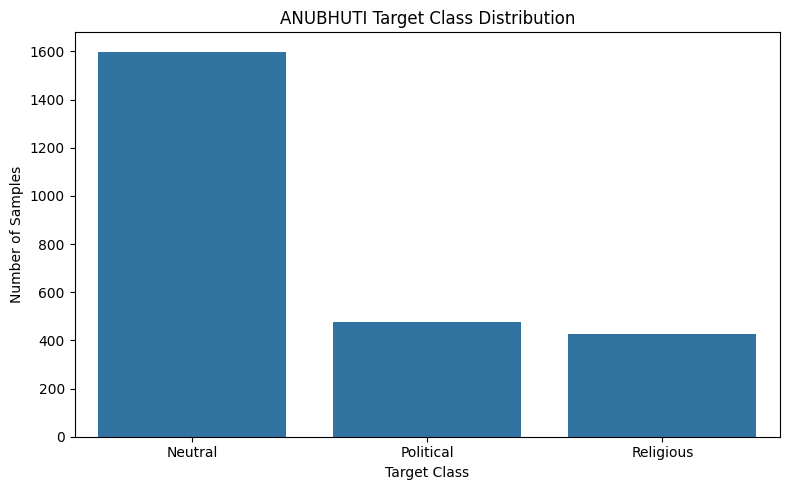

In [6]:
plt.figure(figsize=(8, 5))

class_counts = df[TARGET_COLUMN].value_counts()

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("ANUBHUTI Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.tight_layout()

class_dist_path = FIG_DIR / "01_class_distribution.png"
plt.savefig(class_dist_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# CELL 7 — Handle missing text correctly

In [7]:
# Convert text columns to string while preserving missing values
for dialect in DIALECTS:
    df[dialect] = df[dialect].where(
        df[dialect].notna(),
        np.nan
    )

# Show missing text rows
for dialect in DIALECTS:
    missing_rows = df[df[dialect].isna()]
    if len(missing_rows) > 0:
        print(f"\nMissing {dialect} rows:")
        print(missing_rows[[dialect, TARGET_COLUMN]])


Missing Chittagong rows:
     Chittagong   Target
1930        NaN  Neutral


# CELL 8 — Create one global stratified split

In [8]:
all_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=df[TARGET_COLUMN]
)

train_indices = np.array(sorted(train_indices))
test_indices = np.array(sorted(test_indices))

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))

print("\nTraining class distribution:")
print(df.iloc[train_indices][TARGET_COLUMN].value_counts())

print("\nTesting class distribution:")
print(df.iloc[test_indices][TARGET_COLUMN].value_counts())

# Save split indices for reproducibility
np.save(LOG_DIR / "train_indices.npy", train_indices)
np.save(LOG_DIR / "test_indices.npy", test_indices)

Training samples: 2000
Testing samples: 500

Training class distribution:
Target
Neutral      1279
Political     381
Religious     340
Name: count, dtype: int64

Testing class distribution:
Target
Neutral      320
Political     95
Religious     85
Name: count, dtype: int64


# CELL 9 — Define metrics

In [9]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred)
    }

# CELL 10 — Define models

In [33]:
def create_models():
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            random_state=SEED
        ),

        "SVM": SVC(
            kernel="linear",
            probability=True,
            random_state=SEED
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=SEED,
            max_depth=None
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1
        ),

        "XGBoost": xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1,
            enable_categorical=False # Explicitly disable categorical feature handling
        )
    }

    return models

# CELL 11 — TF-IDF configuration

In [11]:
TFIDF_CONFIG = {
    "max_features": 5000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "sublinear_tf": True
}

print(TFIDF_CONFIG)

{'max_features': 5000, 'ngram_range': (1, 2), 'min_df': 2, 'sublinear_tf': True}


# CELL 12 — Within-dialect baseline experiment

In [13]:
baseline_results = []
baseline_predictions = {}
baseline_models = {}
baseline_vectorizers = {}

# Encode target column once before the loop
label_encoder = LabelEncoder()
df[TARGET_COLUMN] = label_encoder.fit_transform(df[TARGET_COLUMN])

for dialect in DIALECTS:

    print("\n" + "=" * 70)
    print(f"PROCESSING DIALECT: {dialect}")
    print("=" * 70)

    # Remove missing text rows only for this dialect
    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    dialect_test_idx = [
        idx for idx in test_indices
        if valid_mask[idx]
    ]

    X_train_text = (
        df.loc[dialect_train_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    X_test_text = (
        df.loc[dialect_test_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    y_train = (
        df.loc[dialect_train_idx, TARGET_COLUMN]
        .values
    )

    y_test = (
        df.loc[dialect_test_idx, TARGET_COLUMN]
        .values
    )

    # IMPORTANT:
    # Fit TF-IDF ONLY on training data
    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    baseline_vectorizers[dialect] = vectorizer

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    dialect_results = {}
    dialect_predictions = {}

    for model_name, model in create_models().items():

        print(f"Training {model_name}...")

        model_instance = clone(model)
        model_instance.fit(X_train, y_train)

        y_pred = model_instance.predict(X_test)

        metrics = calculate_metrics(y_test, y_pred)

        result = {
            "dialect": dialect,
            "model": model_name,
            "train_samples": len(y_train),
            "test_samples": len(y_test),
            **metrics
        }

        baseline_results.append(result)

        dialect_results[model_name] = result
        dialect_predictions[model_name] = y_pred

        baseline_models[(dialect, model_name)] = model_instance

    baseline_predictions[dialect] = {
        "y_test": y_test,
        "predictions": dialect_predictions
    }

baseline_df = pd.DataFrame(baseline_results)

baseline_df.to_csv(
    TABLE_DIR / "baseline_results.csv",
    index=False
)

print("\nBaseline experiment completed.")
display(baseline_df.round(4))



PROCESSING DIALECT: Chittagong
Train shape: (2000, 2435)
Test shape : (499, 2435)
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

PROCESSING DIALECT: Noakhali
Train shape: (2000, 2002)
Test shape : (500, 2002)
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

PROCESSING DIALECT: Sylhet
Train shape: (2000, 2123)
Test shape : (500, 2123)
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

PROCESSING DIALECT: Mymenshingh
Train shape: (2000, 2121)
Test shape : (500, 2121)
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

Baseline experiment completed.


,dialect,model,train_samples,test_samples,accuracy,precision_macro,recall_macro,f1_macro,mcc,cohen_kappa
0,Chittagong,Logistic Regression,2000,499,0.7776,0.8451,0.6088,0.6672,0.5468,0.4940
1,Chittagong,SVM,2000,499,0.8116,0.8608,0.6767,0.7334,0.6226,0.5889
2,Chittagong,Decision Tree,2000,499,0.7475,0.7060,0.6408,0.6666,0.4912,0.4849
3,Chittagong,Random Forest,2000,499,0.8016,0.8359,0.6673,0.7192,0.5994,0.5689
4,Chittagong,XGBoost,2000,499,0.8116,0.8473,0.6820,0.7352,0.6215,0.5930
5,Noakhali,Logistic Regression,2000,500,0.7940,0.8389,0.6484,0.7043,0.5818,0.5452
6,Noakhali,SVM,2000,500,0.8140,0.8342,0.6971,0.7444,0.6255,0.6046
7,Noakhali,Decision Tree,2000,500,0.7620,0.7092,0.6831,0.6949,0.5344,0.5332
8,Noakhali,Random Forest,2000,500,0.8120,0.8263,0.7001,0.7429,0.6217,0.6029
9,Noakhali,XGBoost,2000,500,0.8240,0.8509,0.7150,0.7578,0.6488,0.6284


# CELL 13 — Baseline summary table

In [14]:
baseline_summary = (
    baseline_df
    .pivot_table(
        index="dialect",
        columns="model",
        values="accuracy"
    )
)

print("Accuracy by dialect and model:")
display((baseline_summary * 100).round(2))

baseline_summary.to_csv(
    TABLE_DIR / "baseline_accuracy_matrix.csv"
)

Accuracy by dialect and model:


model,Decision Tree,Logistic Regression,Random Forest,SVM,XGBoost
dialect,,,,,
Chittagong,74.75,77.76,80.16,81.16,81.16
Mymenshingh,76.40,79.60,80.40,80.60,81.00
Noakhali,76.20,79.40,81.20,81.40,82.40
Sylhet,77.40,79.40,81.00,81.40,81.40


# CELL 14 — Best baseline model per dialect

In [15]:
best_baseline_rows = []

for dialect in DIALECTS:

    dialect_df = baseline_df[
        baseline_df["dialect"] == dialect
    ]

    best_row = dialect_df.loc[
        dialect_df["accuracy"].idxmax()
    ]

    best_baseline_rows.append(best_row)

best_baseline_df = pd.DataFrame(best_baseline_rows)

print("Best baseline model per dialect:")
display(best_baseline_df.round(4))

best_baseline_df.to_csv(
    TABLE_DIR / "best_baseline_models.csv",
    index=False
)

average_baseline_accuracy = best_baseline_df["accuracy"].mean()

print(
    f"\nAverage best-model accuracy: "
    f"{average_baseline_accuracy * 100:.2f}%"
)

Best baseline model per dialect:


,dialect,model,train_samples,test_samples,accuracy,precision_macro,recall_macro,f1_macro,mcc,cohen_kappa
1,Chittagong,SVM,2000,499,0.8116,0.8608,0.6767,0.7334,0.6226,0.5889
9,Noakhali,XGBoost,2000,500,0.8240,0.8509,0.7150,0.7578,0.6488,0.6284
11,Sylhet,SVM,2000,500,0.8140,0.8461,0.6954,0.7450,0.6260,0.6016
19,Mymenshingh,XGBoost,2000,500,0.8100,0.8348,0.6880,0.7380,0.6164,0.5936



Average best-model accuracy: 81.49%


# CELL 15 — 5-fold CV generalization check

In [16]:
cv_results = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for dialect in DIALECTS:

    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    X_text = (
        df.loc[dialect_train_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    y = (
        df.loc[dialect_train_idx, TARGET_COLUMN]
        .values
    )

    print(f"\nCross-validation: {dialect}")

    for model_name, model in create_models().items():

        pipeline = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(**TFIDF_CONFIG)
            ),
            (
                "model",
                clone(model)
            )
        ])

        scores = cross_validate(
            pipeline,
            X_text,
            y,
            cv=cv,
            scoring={
                "accuracy": "accuracy",
                "f1_macro": "f1_macro"
            },
            n_jobs=1
        )

        cv_results.append({
            "dialect": dialect,
            "model": model_name,
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
            "cv_f1_macro_std": scores["test_f1_macro"].std()
        })

cv_df = pd.DataFrame(cv_results)

cv_df.to_csv(
    TABLE_DIR / "five_fold_cross_validation.csv",
    index=False
)

display(cv_df.round(4))


Cross-validation: Chittagong

Cross-validation: Noakhali

Cross-validation: Sylhet

Cross-validation: Mymenshingh


,dialect,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
0,Chittagong,Logistic Regression,0.7885,0.0177,0.6942,0.0323
1,Chittagong,SVM,0.8130,0.0220,0.7454,0.0323
2,Chittagong,Decision Tree,0.7390,0.0142,0.6751,0.0236
3,Chittagong,Random Forest,0.8000,0.0127,0.7271,0.0212
4,Chittagong,XGBoost,0.7920,0.0125,0.7160,0.0187
5,Noakhali,Logistic Regression,0.7905,0.0120,0.6990,0.0239
6,Noakhali,SVM,0.8235,0.0072,0.7566,0.0130
7,Noakhali,Decision Tree,0.7630,0.0162,0.7064,0.0233
8,Noakhali,Random Forest,0.8215,0.0137,0.7586,0.0192
9,Noakhali,XGBoost,0.8145,0.0123,0.7463,0.0177


# CELL 16 — Confusion matrices

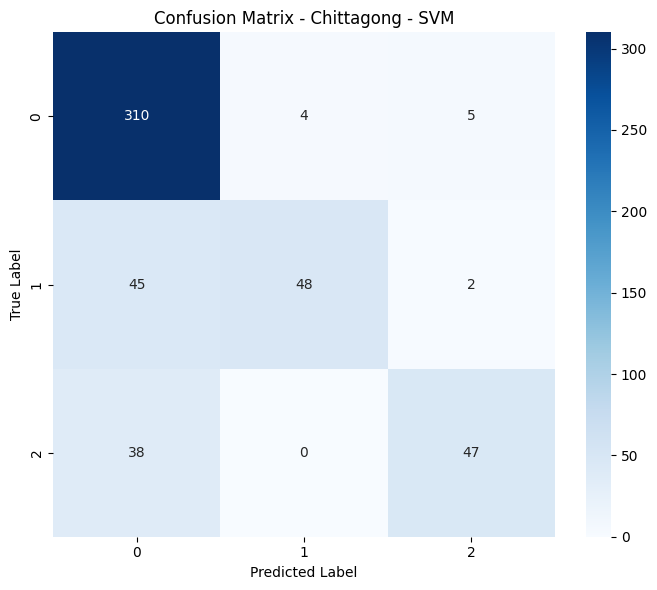

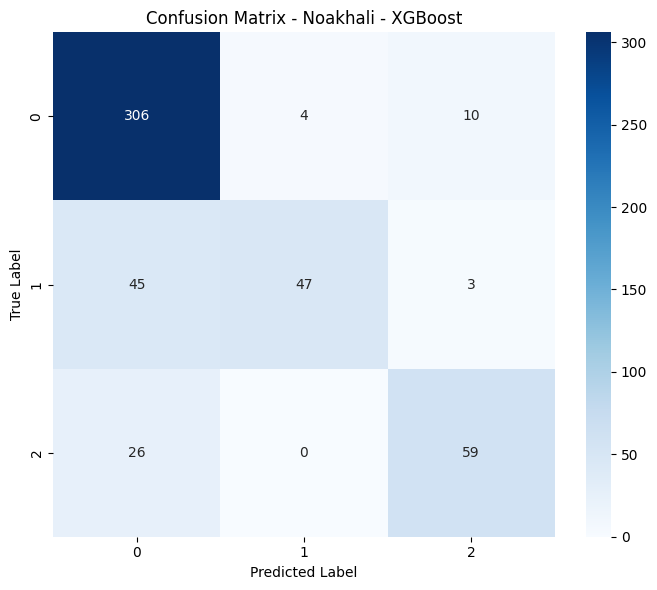

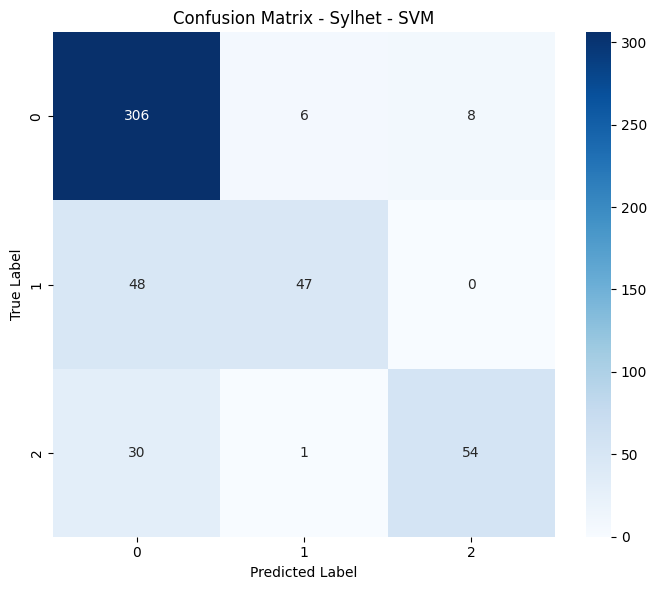

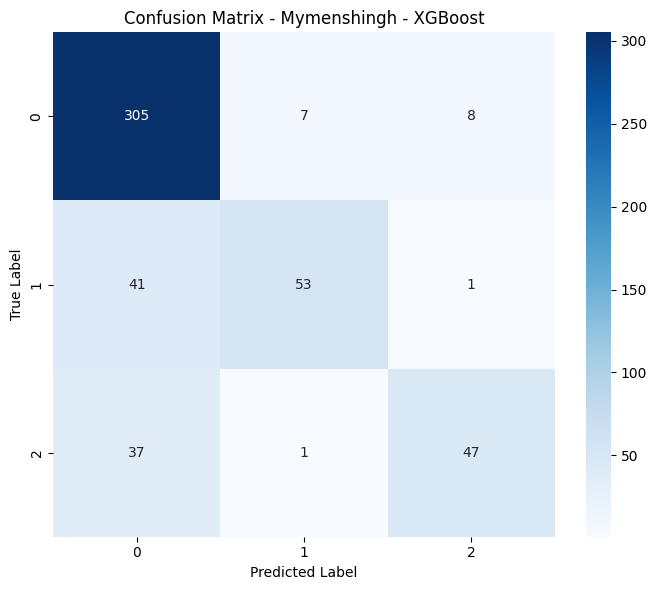

In [17]:
for dialect in DIALECTS:

    dialect_data = baseline_predictions[dialect]

    y_test = dialect_data["y_test"]

    # Plot best model only
    best_model_name = best_baseline_df.loc[
        best_baseline_df["dialect"] == dialect,
        "model"
    ].iloc[0]

    y_pred = dialect_data["predictions"][best_model_name]

    labels = sorted(df[TARGET_COLUMN].unique())

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(
        f"Confusion Matrix - {dialect} - {best_model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    path = FIG_DIR / f"02_confusion_matrix_{dialect}.png"

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# CELL 17 — Stacking and voting ensemble

In [34]:
ensemble_results = []

for dialect in DIALECTS:

    print("\n" + "=" * 70)
    print(f"ENSEMBLE EXPERIMENT: {dialect}")
    print("=" * 70)

    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    dialect_test_idx = [
        idx for idx in test_indices
        if valid_mask[idx]
    ]

    X_train_text = (
        df.loc[dialect_train_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    X_test_text = (
        df.loc[dialect_test_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    y_train = df.loc[
        dialect_train_idx,
        TARGET_COLUMN
    ].values

    y_test = df.loc[
        dialect_test_idx,
        TARGET_COLUMN
    ].values

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    base_models = [
        (
            "lr",
            LogisticRegression(
                max_iter=2000,
                random_state=SEED
            )
        ),
        (
            "svm",
            SVC(
                kernel="linear",
                probability=True,
                random_state=SEED
            )
        ),
        (
            "dt",
            DecisionTreeClassifier(
                random_state=SEED
            )
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=300,
                random_state=SEED,
                n_jobs=-1
            )
        ),
        (
            "xgb",
            xgb.XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=SEED,
                n_jobs=-1,
                enable_categorical=False # Explicitly disable categorical feature handling
            )
        )
    ]

    stacking_model = StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(
            max_iter=2000,
            random_state=SEED
        ),
        cv=5,
        stack_method="auto",
        n_jobs=-1
    )

    voting_model = VotingClassifier(
        estimators=base_models,
        voting="soft",
        n_jobs=-1
    )

    for ensemble_name, model in [
        ("Stacking", stacking_model),
        ("Voting", voting_model)
    ]:

        print(f"Training {ensemble_name}...")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        metrics = calculate_metrics(y_test, y_pred)

        ensemble_results.append({
            "dialect": dialect,
            "ensemble": ensemble_name,
            **metrics
        })

ensemble_df = pd.DataFrame(
    ensemble_results
)

ensemble_df.to_csv(
    TABLE_DIR / "ensemble_results.csv",
    index=False
)

display(ensemble_df.round(4))


ENSEMBLE EXPERIMENT: Chittagong
Training Stacking...
Training Voting...

ENSEMBLE EXPERIMENT: Noakhali
Training Stacking...
Training Voting...

ENSEMBLE EXPERIMENT: Sylhet
Training Stacking...
Training Voting...

ENSEMBLE EXPERIMENT: Mymenshingh
Training Stacking...
Training Voting...


,dialect,ensemble,accuracy,precision_macro,recall_macro,f1_macro,mcc,cohen_kappa
0,Chittagong,Stacking,0.8297,0.8566,0.7206,0.7691,0.6601,0.6405
1,Chittagong,Voting,0.8116,0.8399,0.6882,0.7380,0.6213,0.5963
2,Noakhali,Stacking,0.8360,0.8476,0.7410,0.7810,0.6733,0.6601
3,Noakhali,Voting,0.8240,0.8238,0.7303,0.7650,0.6486,0.6374
4,Sylhet,Stacking,0.8220,0.8410,0.7165,0.7589,0.6437,0.6255
5,Sylhet,Voting,0.8260,0.8500,0.7181,0.7637,0.6521,0.6324
6,Mymenshingh,Stacking,0.8220,0.8318,0.7218,0.7633,0.6431,0.6295
7,Mymenshingh,Voting,0.8120,0.8128,0.7145,0.7521,0.6225,0.6110


# CELL 18 — Ensemble comparison figure

<Figure size 1000x600 with 0 Axes>

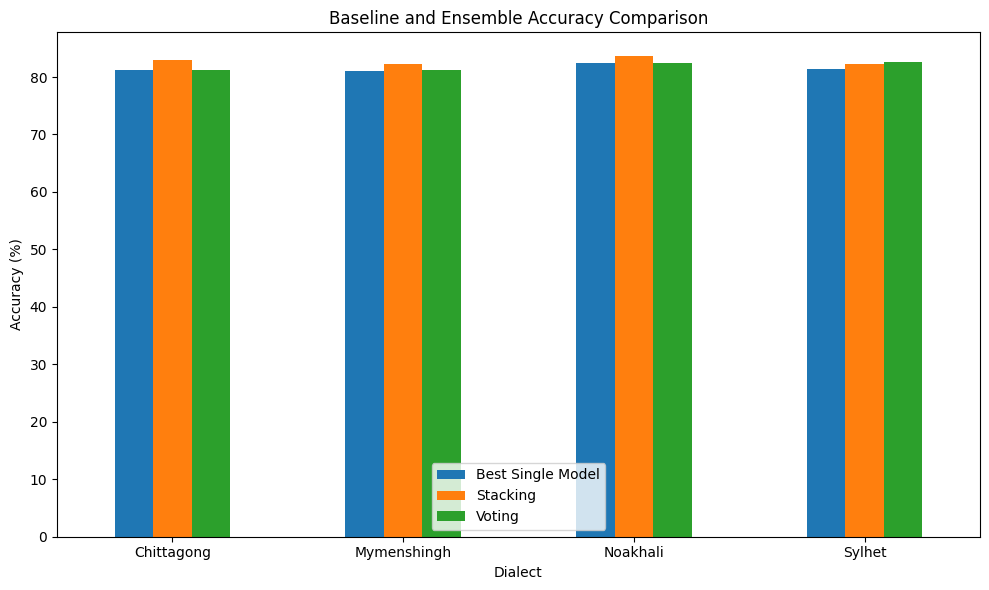

In [19]:
ensemble_plot = ensemble_df.pivot(
    index="dialect",
    columns="ensemble",
    values="accuracy"
)

best_single_accuracy = (
    best_baseline_df
    .set_index("dialect")["accuracy"]
)

comparison_df = ensemble_plot.copy()

comparison_df["Best Single Model"] = best_single_accuracy

comparison_df = comparison_df[
    ["Best Single Model", "Stacking", "Voting"]
]

plt.figure(figsize=(10, 6))

comparison_df.mul(100).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline and Ensemble Accuracy Comparison")
plt.xlabel("Dialect")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

path = FIG_DIR / "03_ensemble_comparison.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# CELL 19 — Correct Cross-Dialect Transfer Learning

In [36]:
transfer_results = []

for source_dialect in DIALECTS:

    for target_dialect in DIALECTS:

        if source_dialect == target_dialect:
            continue

        print("\n" + "-" * 70)
        print(
            f"TRANSFER: {source_dialect} -> {target_dialect}"
        )
        print("-" * 70)

        source_valid = df[source_dialect].notna().values
        target_valid = df[target_dialect].notna().values

        # Source training rows
        source_train_idx = [
            idx for idx in train_indices
            if source_valid[idx]
        ]

        # Target testing rows
        target_test_idx = [
            idx for idx in test_indices
            if target_valid[idx]
        ]

        X_source_text = (
            df.loc[
                source_train_idx,
                source_dialect
            ]
            .astype(str)
            .str.strip()
            .values
        )

        y_source = df.loc[
            source_train_idx,
            TARGET_COLUMN
        ].values

        X_target_text = (
            df.loc[
                target_test_idx,
                target_dialect
            ]
            .astype(str)
            .str.strip()
            .values
        )

        y_target = df.loc[
            target_test_idx,
            TARGET_COLUMN
        ].values

        # CRITICAL:
        # Fit vectorizer ONLY on source training data.
        transfer_vectorizer = TfidfVectorizer(
            **TFIDF_CONFIG
        )

        X_source = transfer_vectorizer.fit_transform(
            X_source_text
        )

        # Transform target text using the SAME source vectorizer.
        X_target = transfer_vectorizer.transform(
            X_target_text
        )

        print(
            "Source feature shape:",
            X_source.shape
        )

        print(
            "Target feature shape:",
            X_target.shape
        )

        # Use XGBoost for standardized transfer benchmark
        transfer_model = xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1,
            enable_categorical=False # Explicitly disable categorical feature handling
        )

        transfer_model.fit(
            X_source,
            y_source
        )

        y_pred = transfer_model.predict(
            X_target
        )

        metrics = calculate_metrics(
            y_target,
            y_pred
        )

        transfer_results.append({
            "source_dialect": source_dialect,
            "target_dialect": target_dialect,
            **metrics
        })

transfer_df = pd.DataFrame(
    transfer_results
)

transfer_df.to_csv(
    TABLE_DIR / "cross_dialect_transfer_results.csv",
    index=False
)

display(transfer_df.round(4))


----------------------------------------------------------------------
TRANSFER: Chittagong -> Noakhali
----------------------------------------------------------------------
Source feature shape: (2000, 2435)
Target feature shape: (500, 2435)

----------------------------------------------------------------------
TRANSFER: Chittagong -> Sylhet
----------------------------------------------------------------------
Source feature shape: (2000, 2435)
Target feature shape: (500, 2435)

----------------------------------------------------------------------
TRANSFER: Chittagong -> Mymenshingh
----------------------------------------------------------------------
Source feature shape: (2000, 2435)
Target feature shape: (500, 2435)

----------------------------------------------------------------------
TRANSFER: Noakhali -> Chittagong
----------------------------------------------------------------------
Source feature shape: (2000, 2002)
Target feature shape: (499, 2002)

------------------

,source_dialect,target_dialect,accuracy,precision_macro,recall_macro,f1_macro,mcc,cohen_kappa
0,Chittagong,Noakhali,0.7680,0.7504,0.6612,0.6948,0.5298,0.5205
1,Chittagong,Sylhet,0.7420,0.7206,0.6522,0.6753,0.4895,0.4857
2,Chittagong,Mymenshingh,0.7360,0.6964,0.6326,0.6563,0.4702,0.4653
3,Noakhali,Chittagong,0.7776,0.7733,0.6474,0.6893,0.5453,0.5250
4,Noakhali,Sylhet,0.7780,0.7580,0.6964,0.7206,0.5611,0.5578
5,Noakhali,Mymenshingh,0.8020,0.8161,0.6789,0.7246,0.5991,0.5767
6,Sylhet,Chittagong,0.7595,0.7320,0.6355,0.6698,0.5087,0.4953
7,Sylhet,Noakhali,0.7640,0.7346,0.6570,0.6869,0.5221,0.5134
8,Sylhet,Mymenshingh,0.7500,0.7259,0.6448,0.6743,0.4976,0.4917
9,Mymenshingh,Chittagong,0.7836,0.7895,0.6538,0.6988,0.5585,0.5384


# CELL 20 — Cross-dialect transfer matrix

In [21]:
transfer_matrix = transfer_df.pivot(
    index="source_dialect",
    columns="target_dialect",
    values="accuracy"
)

print("Cross-Dialect Transfer Accuracy:")
display((transfer_matrix * 100).round(2))

transfer_matrix.to_csv(
    TABLE_DIR / "cross_dialect_accuracy_matrix.csv"
)

Cross-Dialect Transfer Accuracy:


target_dialect,Chittagong,Mymenshingh,Noakhali,Sylhet
source_dialect,,,,
Chittagong,NaN,73.6,76.8,74.2
Mymenshingh,78.36,NaN,81.2,78.4
Noakhali,77.76,80.2,NaN,77.8
Sylhet,75.95,75.0,76.4,NaN


# CELL 21 — Correct cross-dialect average and drop

In [22]:
average_transfer_accuracy = transfer_df["accuracy"].mean()

average_within_accuracy = (
    best_baseline_df["accuracy"].mean()
)

absolute_drop = (
    average_within_accuracy
    - average_transfer_accuracy
)

relative_drop_percent = (
    absolute_drop
    / average_within_accuracy
) * 100

transfer_summary = pd.DataFrame({
    "metric": [
        "Average Within-Dialect Accuracy",
        "Average Cross-Dialect Accuracy",
        "Absolute Accuracy Drop",
        "Relative Accuracy Drop (%)"
    ],
    "value": [
        average_within_accuracy,
        average_transfer_accuracy,
        absolute_drop,
        relative_drop_percent
    ]
})

print("Corrected transfer summary:")
display(transfer_summary)

transfer_summary.to_csv(
    TABLE_DIR / "cross_dialect_summary.csv",
    index=False
)

Corrected transfer summary:


,metric,value
0,Average Within-Dialect Accuracy,0.814906
1,Average Cross-Dialect Accuracy,0.771387
2,Absolute Accuracy Drop,0.043519
3,Relative Accuracy Drop (%),5.340376


# CELL 22 — Cross-dialect heatmap

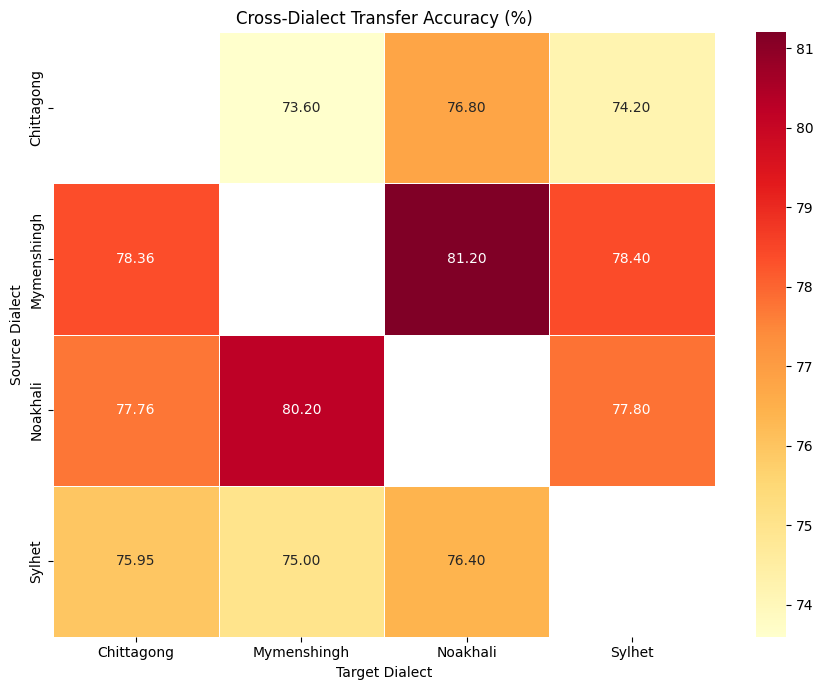

In [23]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    transfer_matrix * 100,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Cross-Dialect Transfer Accuracy (%)")
plt.xlabel("Target Dialect")
plt.ylabel("Source Dialect")
plt.tight_layout()

path = FIG_DIR / "04_cross_dialect_transfer_heatmap.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [24]:
# CELL 23 — SMOTE and ADASYN

In [37]:
imbalance_results = []

for dialect in DIALECTS:

    print("\n" + "=" * 70)
    print(f"IMBALANCE EXPERIMENT: {dialect}")
    print("=" * 70)

    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    dialect_test_idx = [
        idx for idx in test_indices
        if valid_mask[idx]
    ]

    X_train_text = (
        df.loc[dialect_train_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    X_test_text = (
        df.loc[dialect_test_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    y_train = df.loc[
        dialect_train_idx,
        TARGET_COLUMN
    ].values

    y_test = df.loc[
        dialect_test_idx,
        TARGET_COLUMN
    ].values

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    samplers = {
        "Base": None,
        "SMOTE": SMOTE(
            random_state=SEED
        ),
        "ADASYN": ADASYN(
            random_state=SEED
        )
    }

    for sampler_name, sampler in samplers.items():

        print(f"Method: {sampler_name}")

        X_resampled = X_train
        y_resampled = y_train

        if sampler is not None:

            # Convert to dense only for resampling.
            X_dense = X_train.toarray()

            X_resampled, y_resampled = sampler.fit_resample(
                X_dense,
                y_train
            )

        model = xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1,
            enable_categorical=False # Explicitly disable categorical feature handling
        )

        model.fit(
            X_resampled,
            y_resampled
        )

        y_pred = model.predict(
            X_test
        )

        metrics = calculate_metrics(
            y_test,
            y_pred
        )

        imbalance_results.append({
            "dialect": dialect,
            "method": sampler_name,
            **metrics
        })

imbalance_df = pd.DataFrame(
    imbalance_results
)

imbalance_df.to_csv(
    TABLE_DIR / "imbalance_comparison.csv",
    index=False
)

display(imbalance_df.round(4))


IMBALANCE EXPERIMENT: Chittagong
Method: Base
Method: SMOTE
Method: ADASYN

IMBALANCE EXPERIMENT: Noakhali
Method: Base
Method: SMOTE
Method: ADASYN

IMBALANCE EXPERIMENT: Sylhet
Method: Base
Method: SMOTE
Method: ADASYN

IMBALANCE EXPERIMENT: Mymenshingh
Method: Base
Method: SMOTE
Method: ADASYN


,dialect,method,accuracy,precision_macro,recall_macro,f1_macro,mcc,cohen_kappa
0,Chittagong,Base,0.8116,0.8473,0.6820,0.7352,0.6215,0.5930
1,Chittagong,SMOTE,0.1703,0.0568,0.3333,0.0970,0.0000,0.0000
2,Chittagong,ADASYN,0.2064,0.1503,0.3738,0.2016,0.0478,0.0254
3,Noakhali,Base,0.8240,0.8509,0.7150,0.7578,0.6488,0.6284
4,Noakhali,SMOTE,0.1900,0.0633,0.3333,0.1064,0.0000,0.0000
5,Noakhali,ADASYN,0.1900,0.0633,0.3333,0.1064,0.0000,0.0000
6,Sylhet,Base,0.8140,0.8396,0.7016,0.7467,0.6263,0.6048
7,Sylhet,SMOTE,0.1900,0.0633,0.3333,0.1064,0.0000,0.0000
8,Sylhet,ADASYN,0.1900,0.0633,0.3333,0.1064,0.0000,0.0000
9,Mymenshingh,Base,0.8100,0.8348,0.6880,0.7380,0.6164,0.5936


In [26]:
# CELL 24 — SMOTE/ADASYN summary

In [27]:
imbalance_accuracy = imbalance_df.pivot(
    index="dialect",
    columns="method",
    values="accuracy"
)

print("Imbalance handling accuracy:")
display((imbalance_accuracy * 100).round(2))

average_imbalance = (
    imbalance_df
    .groupby("method")["accuracy"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage accuracy:")
display((average_imbalance * 100).round(2))

imbalance_accuracy.to_csv(
    TABLE_DIR / "imbalance_accuracy_matrix.csv"
)

Imbalance handling accuracy:


method,ADASYN,Base,SMOTE
dialect,,,
Chittagong,20.64,81.16,17.03
Mymenshingh,19.00,81.00,19.00
Noakhali,19.00,82.40,19.00
Sylhet,19.00,81.40,19.00



Average accuracy:


,accuracy
method,
Base,81.49
ADASYN,19.41
SMOTE,18.51


# CELL 25 — Proper XGBoost feature importance

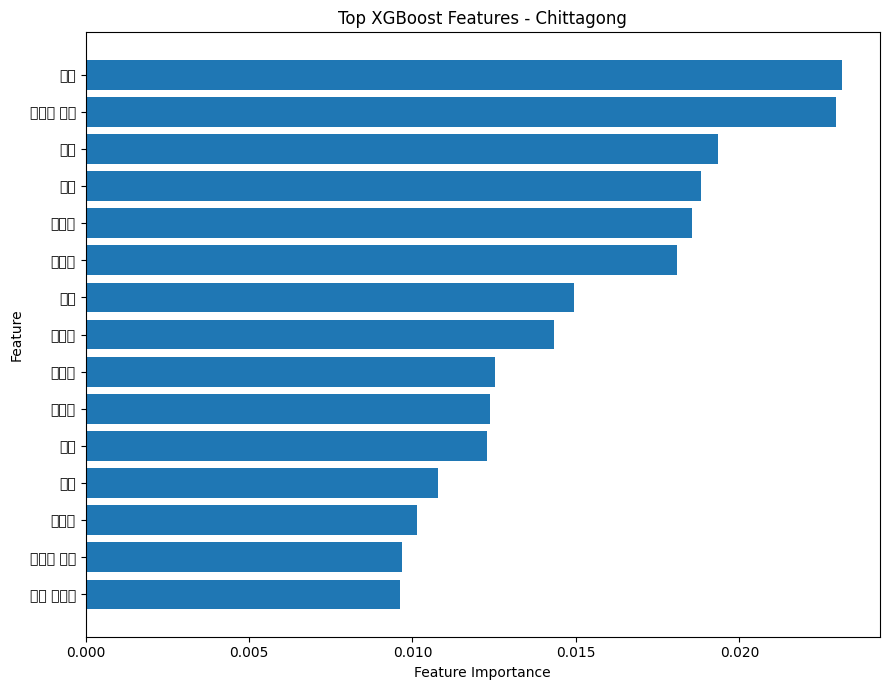

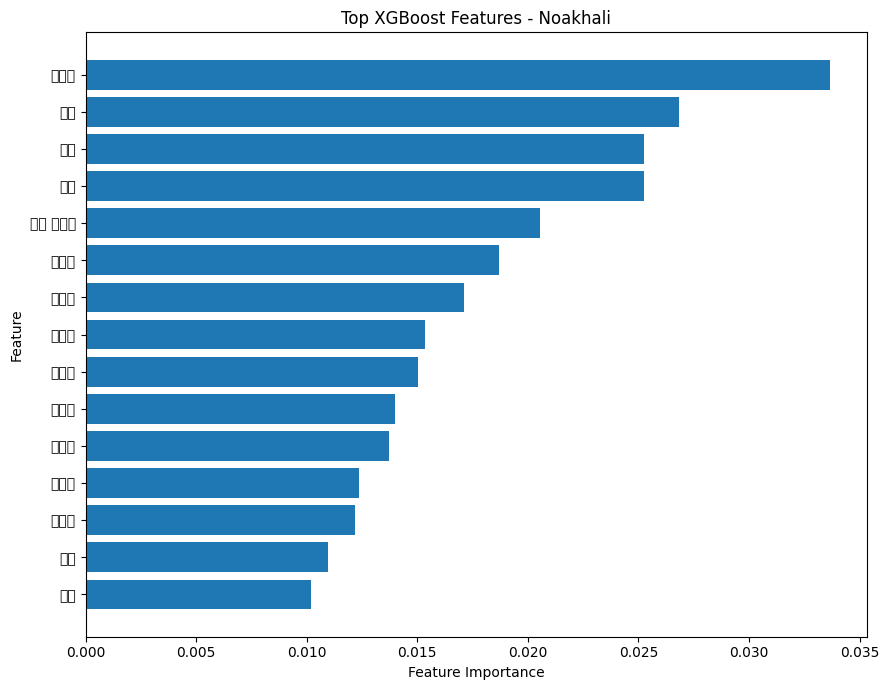

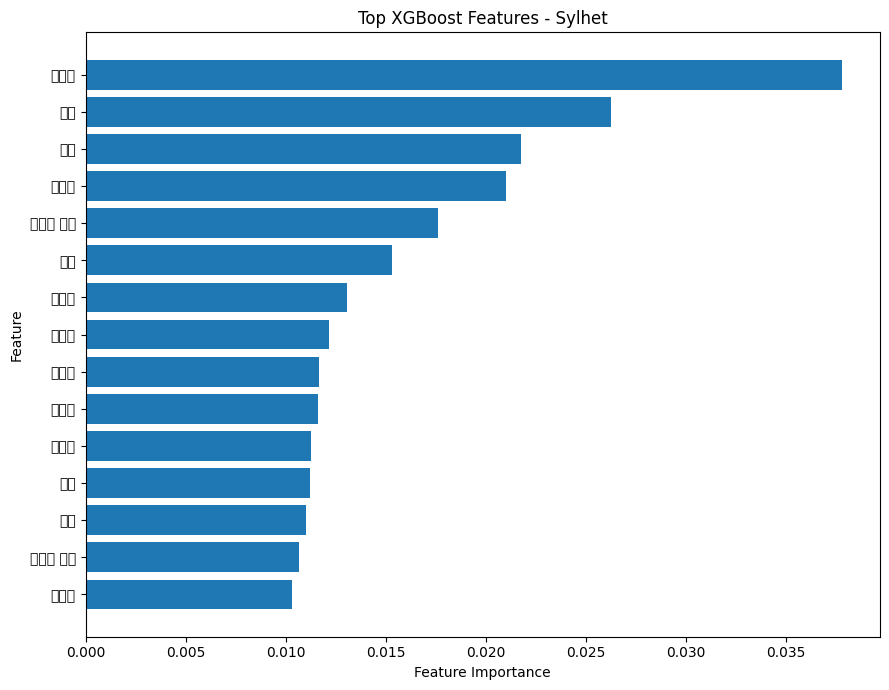

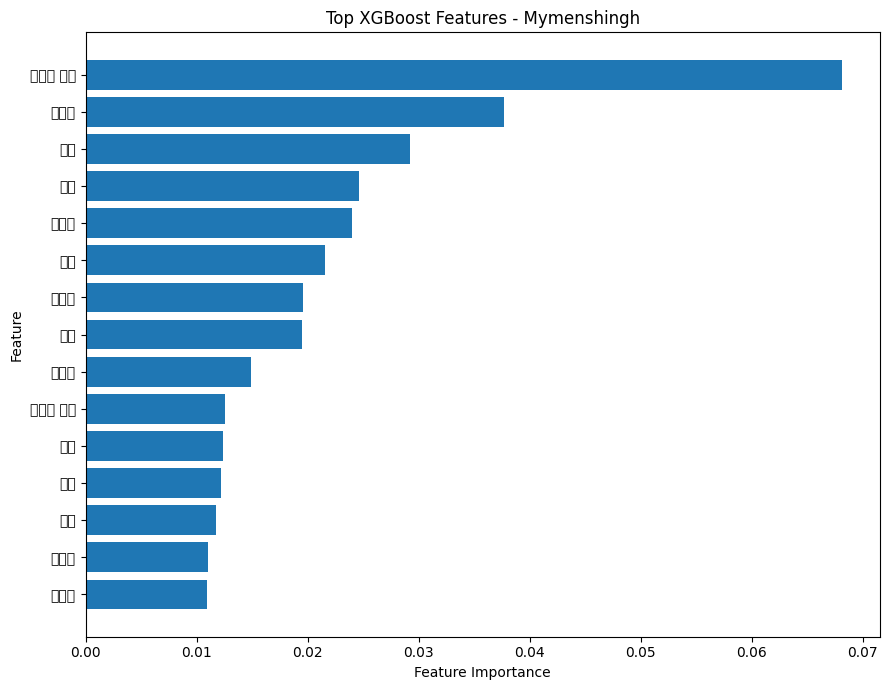

In [39]:
feature_importance_results = {}

for dialect in DIALECTS:

    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    dialect_test_idx = [
        idx for idx in test_indices
        if valid_mask[idx]
    ]

    X_train_text = (
        df.loc[dialect_train_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    X_test_text = (
        df.loc[dialect_test_idx, dialect]
        .astype(str)
        .str.strip()
        .values
    )

    y_train = df.loc[
        dialect_train_idx,
        TARGET_COLUMN
    ].values

    y_test = df.loc[
        dialect_test_idx,
        TARGET_COLUMN
    ].values

    vectorizer = TfidfVectorizer(**TFIDF_CONFIG)

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1,
        enable_categorical=False # Explicitly disable categorical feature handling
    )

    model.fit(
        X_train,
        y_train
    )

    feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    importances = model.feature_importances_

    top_indices = np.argsort(
        importances
    )[::-1]

    top_indices = top_indices[
        importances[top_indices] > 0
    ]

    top_n = min(
        20,
        len(top_indices)
    )

    top_features = pd.DataFrame({
        "feature": feature_names[
            top_indices[:top_n]
        ],
        "importance": importances[
            top_indices[:top_n]
        ]
    })

    feature_importance_results[dialect] = {
        "model": model,
        "vectorizer": vectorizer,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "top_features": top_features
    }

    top_features.to_csv(
        TABLE_DIR / f"top_features_{dialect}.csv",
        index=False
    )

    # Plot top features
    plt.figure(figsize=(9, 7))

    plot_df = top_features.head(15).sort_values(
        "importance"
    )

    plt.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    plt.title(
        f"Top XGBoost Features - {dialect}"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()

    path = FIG_DIR / (
        f"05_xgboost_feature_importance_{dialect}.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# CELL 26 — Proper simultaneous Top-1 / Top-3 / Top-5 ablation

In [40]:
ablation_results = []

for dialect in DIALECTS:

    print("\n" + "=" * 70)
    print(f"ABLATION STUDY: {dialect}")
    print("=" * 70)

    data = feature_importance_results[dialect]

    vectorizer = data["vectorizer"]

    X_train = data["X_train"]
    X_test = data["X_test"]

    y_train = data["y_train"]
    y_test = data["y_test"]

    original_feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    importances = data["model"].feature_importances_

    ranked_indices = np.argsort(
        importances
    )[::-1]

    base_model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1,
        enable_categorical=False # Explicitly disable categorical feature handling
    )

    base_model.fit(
        X_train,
        y_train
    )

    base_pred = base_model.predict(
        X_test
    )

    base_accuracy = accuracy_score(
        y_test,
        base_pred
    )

    ablation_results.append({
        "dialect": dialect,
        "removed_features": 0,
        "accuracy": base_accuracy,
        "accuracy_drop": 0.0
    })

    for k in [1, 3, 5]:

        remove_indices = ranked_indices[:k]

        keep_mask = np.ones(
            X_train.shape[1],
            dtype=bool
        )

        keep_mask[remove_indices] = False

        X_train_reduced = X_train[:, keep_mask]
        X_test_reduced = X_test[:, keep_mask]

        model = xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1,
            enable_categorical=False # Explicitly disable categorical feature handling
        )

        model.fit(
            X_train_reduced,
            y_train
        )

        y_pred = model.predict(
            X_test_reduced
        )

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        ablation_results.append({
            "dialect": dialect,
            "removed_features": k,
            "accuracy": accuracy,
            "accuracy_drop": (
                base_accuracy - accuracy
            )
        })

ablation_df = pd.DataFrame(
    ablation_results
)

ablation_df.to_csv(
    TABLE_DIR / "ablation_results.csv",
    index=False
)

display(
    ablation_df.round(4)
)


ABLATION STUDY: Chittagong

ABLATION STUDY: Noakhali

ABLATION STUDY: Sylhet

ABLATION STUDY: Mymenshingh


,dialect,removed_features,accuracy,accuracy_drop
0,Chittagong,0,0.8116,0.0000
1,Chittagong,1,0.7956,0.0160
2,Chittagong,3,0.7715,0.0401
3,Chittagong,5,0.7595,0.0521
4,Noakhali,0,0.8240,0.0000
5,Noakhali,1,0.8020,0.0220
6,Noakhali,3,0.7800,0.0440
7,Noakhali,5,0.7340,0.0900
8,Sylhet,0,0.8140,0.0000
9,Sylhet,1,0.7940,0.0200


# CELL 27 — Ablation plot

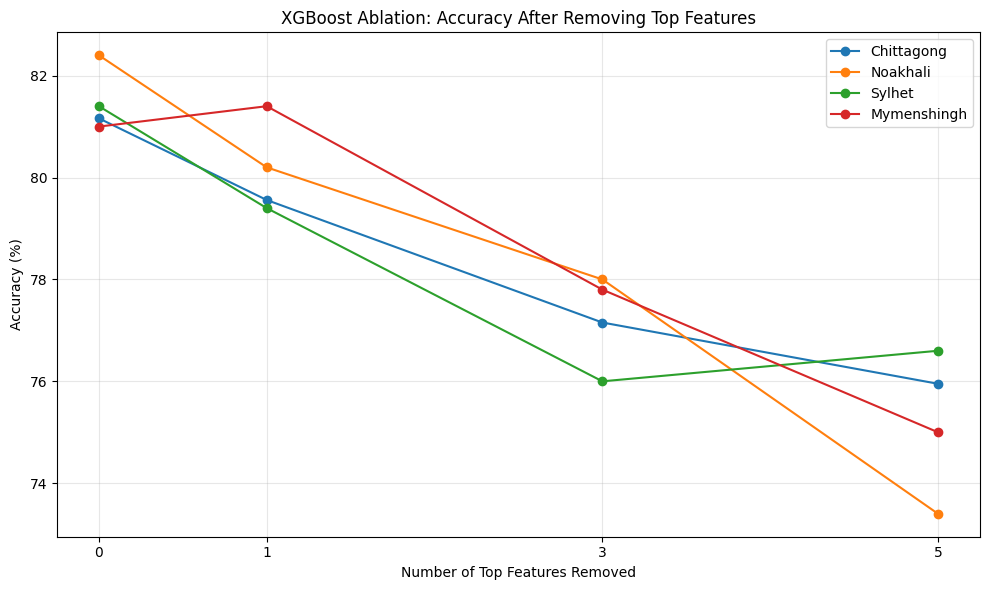

In [30]:
plt.figure(figsize=(10, 6))

for dialect in DIALECTS:

    subset = ablation_df[
        ablation_df["dialect"] == dialect
    ]

    plt.plot(
        subset["removed_features"],
        subset["accuracy"] * 100,
        marker="o",
        label=dialect
    )

plt.title(
    "XGBoost Ablation: Accuracy After Removing Top Features"
)

plt.xlabel(
    "Number of Top Features Removed"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks([0, 1, 3, 5])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = FIG_DIR / "06_ablation_accuracy.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# CELL 28 — SHAP explainability


Generating SHAP analysis for Chittagong...


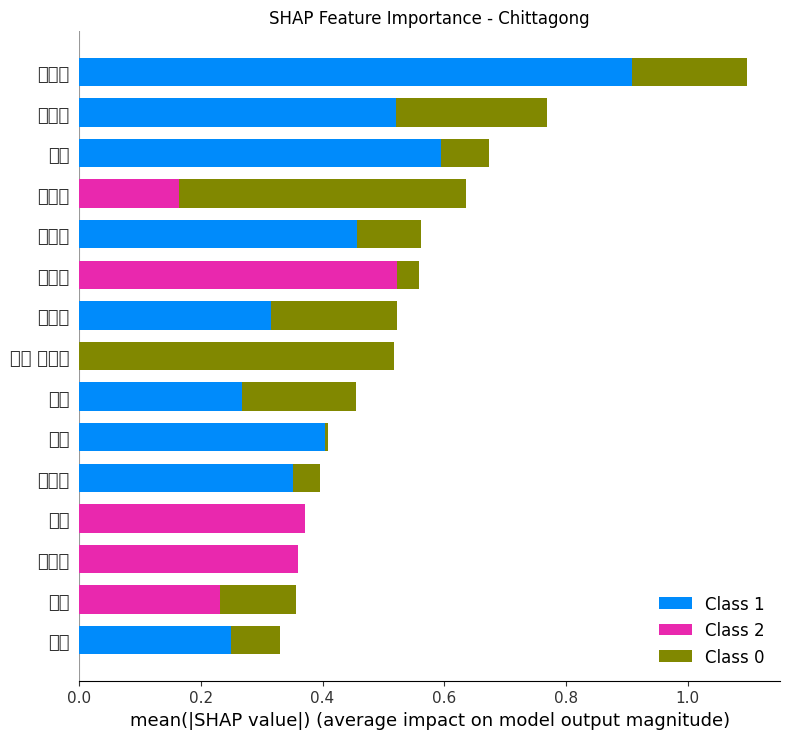

SHAP completed successfully for Chittagong.

Generating SHAP analysis for Noakhali...


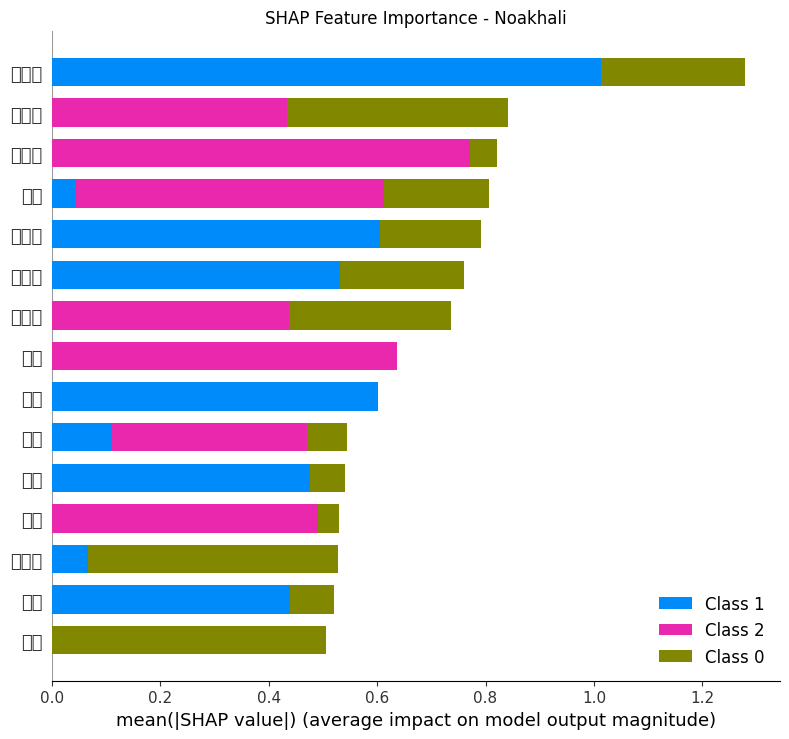

SHAP completed successfully for Noakhali.

Generating SHAP analysis for Sylhet...


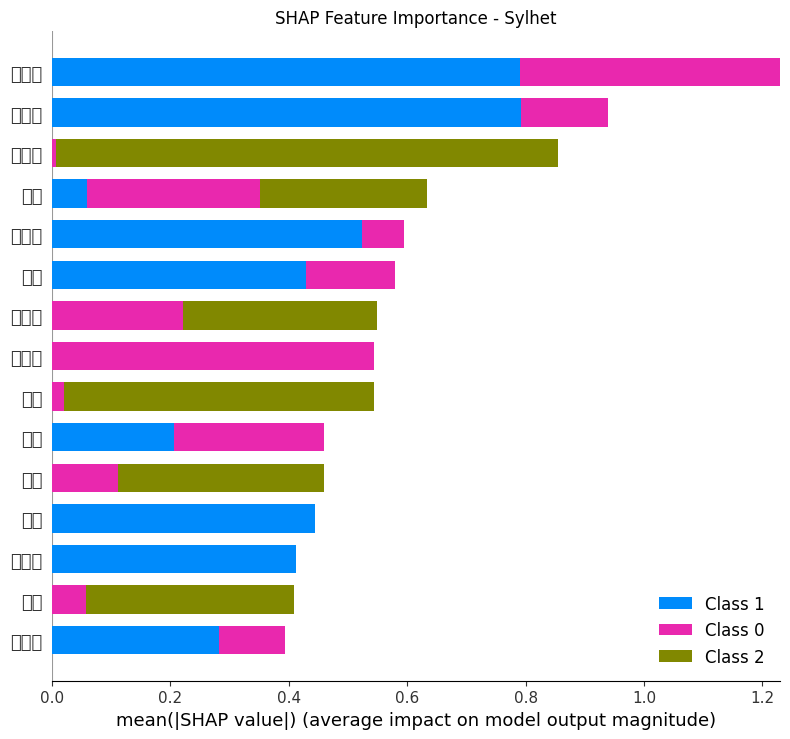

SHAP completed successfully for Sylhet.

Generating SHAP analysis for Mymenshingh...


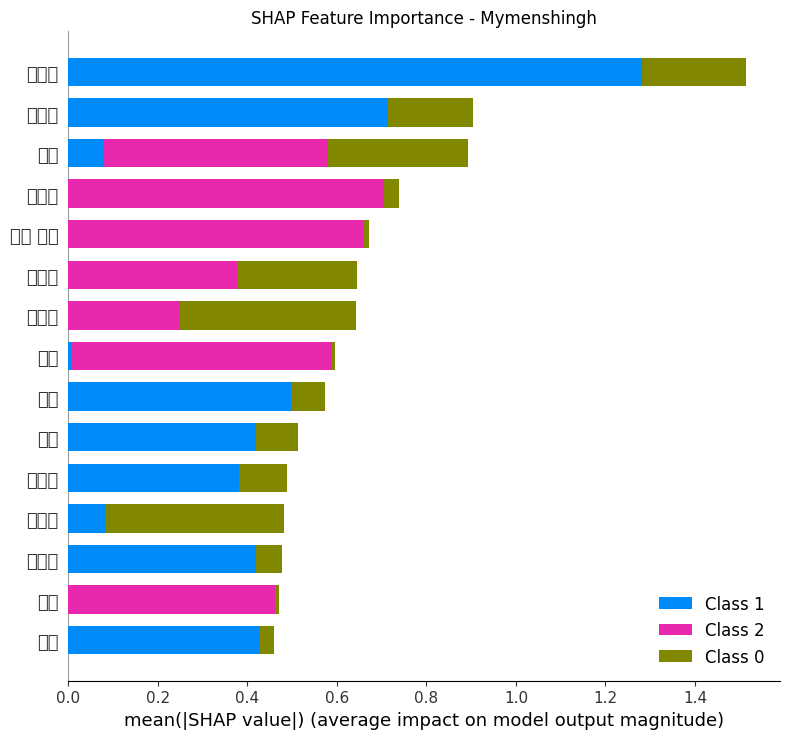

SHAP completed successfully for Mymenshingh.

SHAP analysis completed.


In [41]:
shap_results = {}

for dialect in DIALECTS:

    print(f"\nGenerating SHAP analysis for {dialect}...")

    data = feature_importance_results[dialect]

    model = data["model"]
    X_train = data["X_train"]
    X_test = data["X_test"]
    vectorizer = data["vectorizer"]

    feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    background_size = min(100, X_train.shape[0])
    explanation_size = min(100, X_test.shape[0])

    background_indices = np.random.choice(
        X_train.shape[0],
        size=background_size,
        replace=False
    )

    explanation_indices = np.random.choice(
        X_test.shape[0],
        size=explanation_size,
        replace=False
    )

    background_dense = X_train[
        background_indices
    ].toarray()

    explanation_dense = X_test[
        explanation_indices
    ].toarray()

    try:

        explainer = shap.TreeExplainer(
            model,
            feature_perturbation="tree_path_dependent"
        )

        shap_values = explainer(
            explanation_dense
        )

        shap_results[dialect] = {
            "shap_values": shap_values,
            "feature_names": feature_names
        }

        plt.figure(figsize=(10, 7))

        shap.summary_plot(
            shap_values,
            explanation_dense,
            feature_names=feature_names,
            plot_type="bar",
            max_display=15,
            show=False
        )

        plt.title(
            f"SHAP Feature Importance - {dialect}"
        )

        plt.tight_layout()

        path = FIG_DIR / (
            f"07_SHAP_feature_importance_{dialect}.png"
        )

        plt.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        print(
            f"SHAP completed successfully for {dialect}."
        )

    except Exception as e:

        print(
            f"SHAP failed for {dialect}: "
            f"{type(e).__name__}: {e}"
        )

print("\nSHAP analysis completed.")

# CELL 29 — ROC/AUC analysis

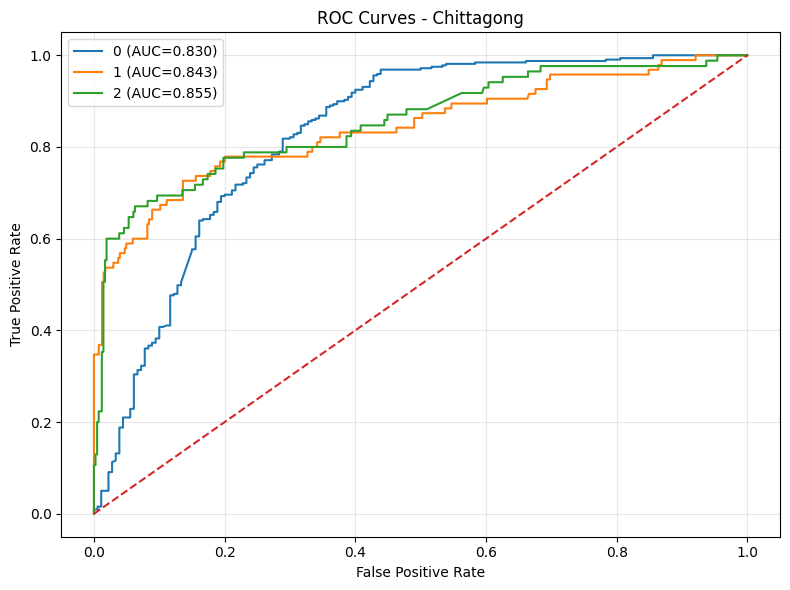

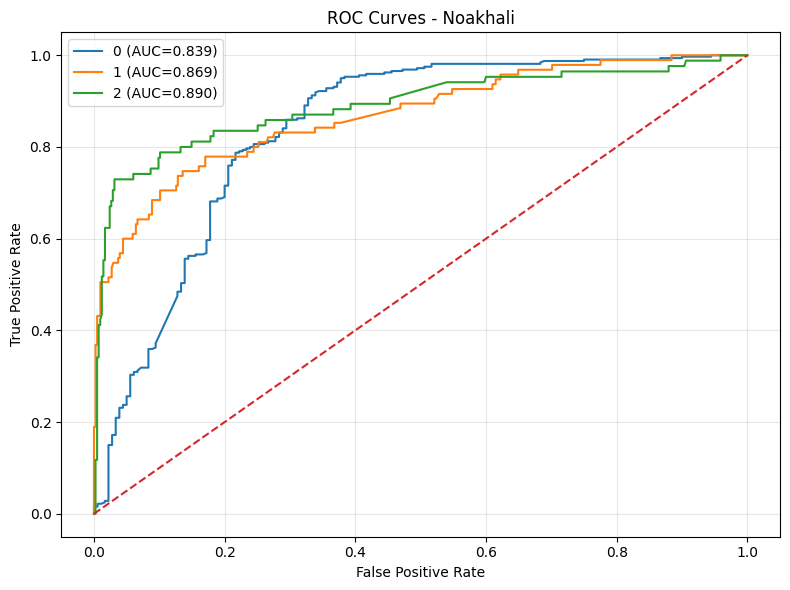

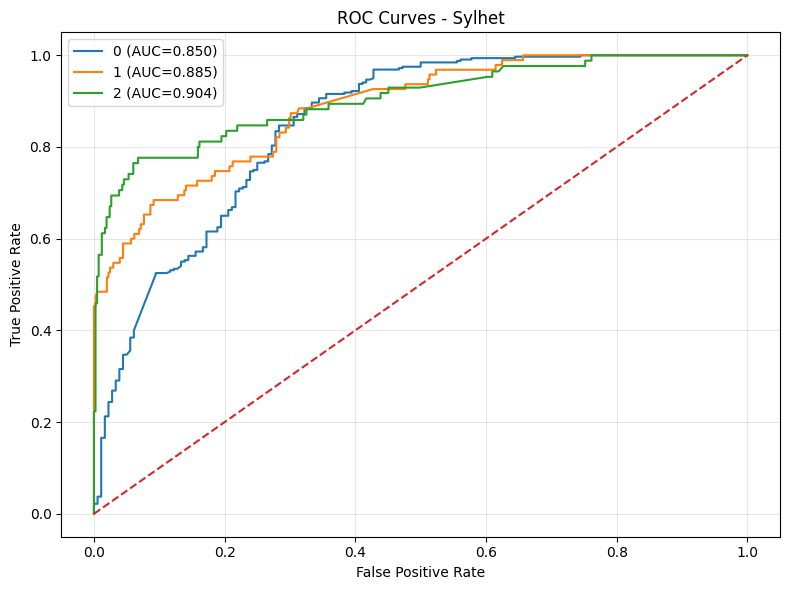

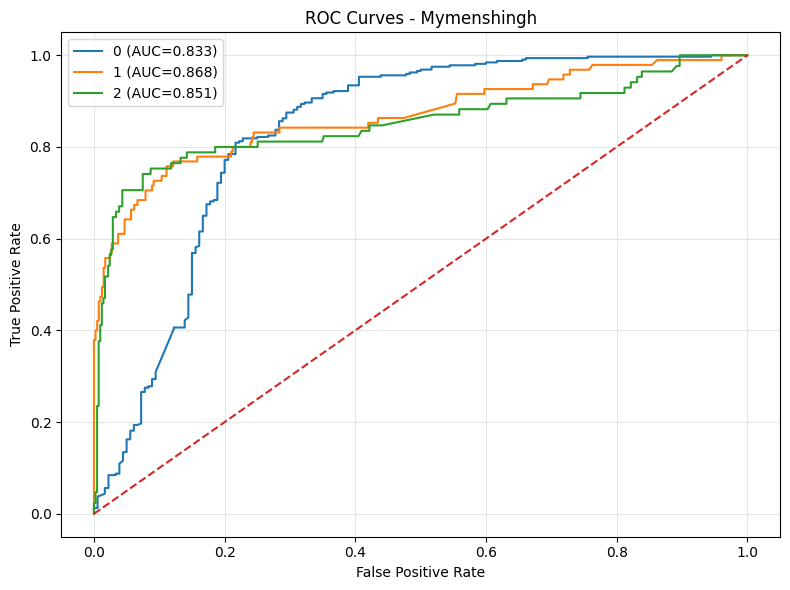

,dialect,macro_auc_ovr,class,auc
0,Chittagong,0.8423,NaN,NaN
1,Chittagong,NaN,0.0,0.8297
2,Chittagong,NaN,1.0,0.8427
3,Chittagong,NaN,2.0,0.8545
4,Noakhali,0.8661,NaN,NaN
5,Noakhali,NaN,0.0,0.8391
6,Noakhali,NaN,1.0,0.8690
7,Noakhali,NaN,2.0,0.8904
8,Sylhet,0.8795,NaN,NaN
9,Sylhet,NaN,0.0,0.8497


In [42]:
roc_results = []

for dialect in DIALECTS:

    valid_mask = df[dialect].notna().values

    dialect_train_idx = [
        idx for idx in train_indices
        if valid_mask[idx]
    ]

    dialect_test_idx = [
        idx for idx in test_indices
        if valid_mask[idx]
    ]

    X_train_text = (
        df.loc[
            dialect_train_idx,
            dialect
        ]
        .astype(str)
        .str.strip()
        .values
    )

    X_test_text = (
        df.loc[
            dialect_test_idx,
            dialect
        ]
        .astype(str)
        .str.strip()
        .values
    )

    y_train = df.loc[
        dialect_train_idx,
        TARGET_COLUMN
    ].values

    y_test = df.loc[
        dialect_test_idx,
        TARGET_COLUMN
    ].values

    vectorizer = TfidfVectorizer(
        **TFIDF_CONFIG
    )

    X_train = vectorizer.fit_transform(
        X_train_text
    )

    X_test = vectorizer.transform(
        X_test_text
    )

    model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    probabilities = model.predict_proba(
        X_test
    )

    classes = model.classes_

    # Multiclass macro ROC-AUC
    macro_auc = roc_auc_score(
        y_test,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    roc_results.append({
        "dialect": dialect,
        "macro_auc_ovr": macro_auc
    })

    # Encode labels
    label_encoder = LabelEncoder()
    label_encoder.fit(classes)

    y_encoded = label_encoder.transform(
        y_test
    )

    plt.figure(figsize=(8, 6))

    for class_index, class_name in enumerate(classes):

        binary_true = (
            y_encoded == class_index
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_true,
            probabilities[:, class_index]
        )

        class_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} (AUC={class_auc:.3f})"
        )

        roc_results.append({
            "dialect": dialect,
            "class": class_name,
            "auc": class_auc
        })

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.title(
        f"ROC Curves - {dialect}"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    path = FIG_DIR / (
        f"08_ROC_{dialect}.png"
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

roc_df = pd.DataFrame(
    roc_results
)

roc_df.to_csv(
    TABLE_DIR / "roc_auc_results.csv",
    index=False
)

display(roc_df.round(4))

# CELL 30 — Generate classification reports

In [43]:
classification_reports = {}

for dialect in DIALECTS:

    dialect_data = baseline_predictions[dialect]

    y_test = dialect_data["y_test"]

    best_model_name = best_baseline_df.loc[
        best_baseline_df["dialect"] == dialect,
        "model"
    ].iloc[0]

    y_pred = dialect_data[
        "predictions"
    ][best_model_name]

    report = classification_report(
        y_test,
        y_pred,
        zero_division=0
    )

    classification_reports[dialect] = report

    with open(
        LOG_DIR / f"classification_report_{dialect}.txt",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(report)

    print(
        f"\nClassification Report - {dialect}"
    )

    print(report)


Classification Report - Chittagong
              precision    recall  f1-score   support

           0       0.79      0.97      0.87       319
           1       0.92      0.51      0.65        95
           2       0.87      0.55      0.68        85

    accuracy                           0.81       499
   macro avg       0.86      0.68      0.73       499
weighted avg       0.83      0.81      0.80       499


Classification Report - Noakhali
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       320
           1       0.92      0.49      0.64        95
           2       0.82      0.69      0.75        85

    accuracy                           0.82       500
   macro avg       0.85      0.72      0.76       500
weighted avg       0.83      0.82      0.81       500


Classification Report - Sylhet
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       320
           1       0.87    

# CELL 31 — Final research summary

In [44]:
final_summary = {
    "dataset_size": int(len(df)),
    "number_of_dialects": len(DIALECTS),
    "dialects": DIALECTS,
    "classes": sorted(
        df[TARGET_COLUMN].unique().tolist()
    ),
    "train_size": int(len(train_indices)),
    "test_size": int(len(test_indices)),
    "average_best_within_dialect_accuracy": float(
        average_within_accuracy
    ),
    "average_cross_dialect_accuracy": float(
        average_transfer_accuracy
    ),
    "absolute_cross_dialect_drop": float(
        absolute_drop
    ),
    "relative_cross_dialect_drop_percent": float(
        relative_drop_percent
    ),
    "best_single_model_overall": (
        best_baseline_df
        .loc[
            best_baseline_df["accuracy"].idxmax(),
            "model"
        ]
    ),
    "best_single_model_accuracy": float(
        best_baseline_df["accuracy"].max()
    ),
    "best_single_model_dialect": (
        best_baseline_df
        .loc[
            best_baseline_df["accuracy"].idxmax(),
            "dialect"
        ]
    ),
    "best_ensemble_accuracy": float(
        ensemble_df["accuracy"].max()
    ),
    "best_ensemble_dialect": (
        ensemble_df
        .loc[
            ensemble_df["accuracy"].idxmax(),
            "dialect"
        ]
    )
}

with open(
    TABLE_DIR / "final_research_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    json.dumps(
        final_summary,
        indent=4,
        ensure_ascii=False
    )
)

{
    "dataset_size": 2500,
    "number_of_dialects": 4,
    "dialects": [
        "Chittagong",
        "Noakhali",
        "Sylhet",
        "Mymenshingh"
    ],
    "classes": [
        0,
        1,
        2
    ],
    "train_size": 2000,
    "test_size": 500,
    "average_best_within_dialect_accuracy": 0.8149058116232465,
    "average_cross_dialect_accuracy": 0.7713867735470942,
    "absolute_cross_dialect_drop": 0.04351903807615232,
    "relative_cross_dialect_drop_percent": 5.340376452766344,
    "best_single_model_overall": "XGBoost",
    "best_single_model_accuracy": 0.824,
    "best_single_model_dialect": "Noakhali",
    "best_ensemble_accuracy": 0.836,
    "best_ensemble_dialect": "Noakhali"
}


# CELL 32 — Create one Excel workbook

In [45]:
excel_path = OUTPUT_DIR / "ANUBHUTI_Final_Results.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    baseline_df.to_excel(
        writer,
        sheet_name="Baseline",
        index=False
    )

    best_baseline_df.to_excel(
        writer,
        sheet_name="Best_Baseline",
        index=False
    )

    cv_df.to_excel(
        writer,
        sheet_name="5Fold_CV",
        index=False
    )

    ensemble_df.to_excel(
        writer,
        sheet_name="Ensemble",
        index=False
    )

    transfer_df.to_excel(
        writer,
        sheet_name="Cross_Dialect",
        index=False
    )

    imbalance_df.to_excel(
        writer,
        sheet_name="SMOTE_ADASYN",
        index=False
    )

    ablation_df.to_excel(
        writer,
        sheet_name="Ablation",
        index=False
    )

    roc_df.to_excel(
        writer,
        sheet_name="ROC_AUC",
        index=False
    )

print(
    f"Excel workbook saved to: {excel_path}"
)

Excel workbook saved to: /content/ANUBHUTI_Research_Results/ANUBHUTI_Final_Results.xlsx


# CELL 33 — Save all important tables

In [46]:
# Save target distribution
target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
) * 100

target_distribution.to_csv(
    TABLE_DIR / "target_distribution.csv",
    index=False
)

# Save dialect statistics
dialect_statistics = []

for dialect in DIALECTS:

    valid_count = df[dialect].notna().sum()

    dialect_statistics.append({
        "dialect": dialect,
        "total_rows": len(df),
        "valid_text_rows": int(valid_count),
        "missing_text_rows": int(
            len(df) - valid_count
        )
    })

dialect_statistics_df = pd.DataFrame(
    dialect_statistics
)

dialect_statistics_df.to_csv(
    TABLE_DIR / "dialect_statistics.csv",
    index=False
)

print("All research tables saved.")

All research tables saved.


In [47]:
# CELL 34 — Save experiment configuration

In [48]:
experiment_config = {
    "seed": SEED,
    "test_size": 0.20,
    "tfidf": TFIDF_CONFIG,
    "models": [
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ensemble_methods": [
        "Stacking",
        "Voting"
    ],
    "cross_validation_folds": 5,
    "metrics": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "MCC",
        "Cohen Kappa",
        "ROC-AUC"
    ],
    "imbalance_methods": [
        "Base",
        "SMOTE",
        "ADASYN"
    ],
    "ablation_feature_counts": [
        1,
        3,
        5
    ],
    "cross_dialect_vectorizer_rule": (
        "Fit TF-IDF on source training data and "
        "transform target test data using the same vectorizer."
    )
}

with open(
    LOG_DIR / "experiment_configuration.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        experiment_config,
        f,
        indent=4
    )

print("Experiment configuration saved.")

Experiment configuration saved.


# CELL 35 — List every generated image

In [49]:
image_files = sorted(
    FIG_DIR.glob("*.png")
)

print(
    f"Total generated images: {len(image_files)}"
)

for image_file in image_files:
    print(image_file.name)

Total generated images: 20
01_class_distribution.png
02_confusion_matrix_Chittagong.png
02_confusion_matrix_Mymenshingh.png
02_confusion_matrix_Noakhali.png
02_confusion_matrix_Sylhet.png
03_ensemble_comparison.png
04_cross_dialect_transfer_heatmap.png
05_xgboost_feature_importance_Chittagong.png
05_xgboost_feature_importance_Mymenshingh.png
05_xgboost_feature_importance_Noakhali.png
05_xgboost_feature_importance_Sylhet.png
06_ablation_accuracy.png
07_SHAP_feature_importance_Chittagong.png
07_SHAP_feature_importance_Mymenshingh.png
07_SHAP_feature_importance_Noakhali.png
07_SHAP_feature_importance_Sylhet.png
08_ROC_Chittagong.png
08_ROC_Mymenshingh.png
08_ROC_Noakhali.png
08_ROC_Sylhet.png


# CELL 36 — Create ZIP containing EVERYTHING

In [50]:
zip_path = "/content/ANUBHUTI_Final_Research_Package.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files_in_root in os.walk(
        OUTPUT_DIR
    ):

        for file_name in files_in_root:

            file_path = os.path.join(
                root,
                file_name
            )

            archive_name = os.path.relpath(
                file_path,
                OUTPUT_DIR.parent
            )

            zipf.write(
                file_path,
                archive_name
            )

print(
    f"ZIP package created: {zip_path}"
)

print(
    f"Size: "
    f"{os.path.getsize(zip_path) / (1024**2):.2f} MB"
)

ZIP package created: /content/ANUBHUTI_Final_Research_Package.zip
Size: 1.70 MB


# CELL 37 — Download everything

In [51]:
files.download(
    zip_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>